<a href="https://www.kaggle.com/code/mohammadrayyankhan/potato-2?scriptVersionId=294988745" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Convolution2D
from keras.preprocessing import image
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib.pyplot  import imshow
import pandas as pd
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense,BatchNormalization
from keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications import DenseNet121

2026-01-30 16:07:30.601452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769789250.819830      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769789250.890524      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769789251.389260      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769789251.389320      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769789251.389323      24 computation_placer.cc:177] computation placer alr

In [2]:
df=keras.utils.image_dataset_from_directory(
"/kaggle/input/potato-leaf-disease-dataset/Potato Leaf Disease Dataset in Uncontrolled Environment"

)

Found 3076 files belonging to 7 classes.


I0000 00:00:1769789269.712123      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769789269.718227      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
classes=df.class_names

In [4]:
len(df)

97

In [5]:
classes

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']

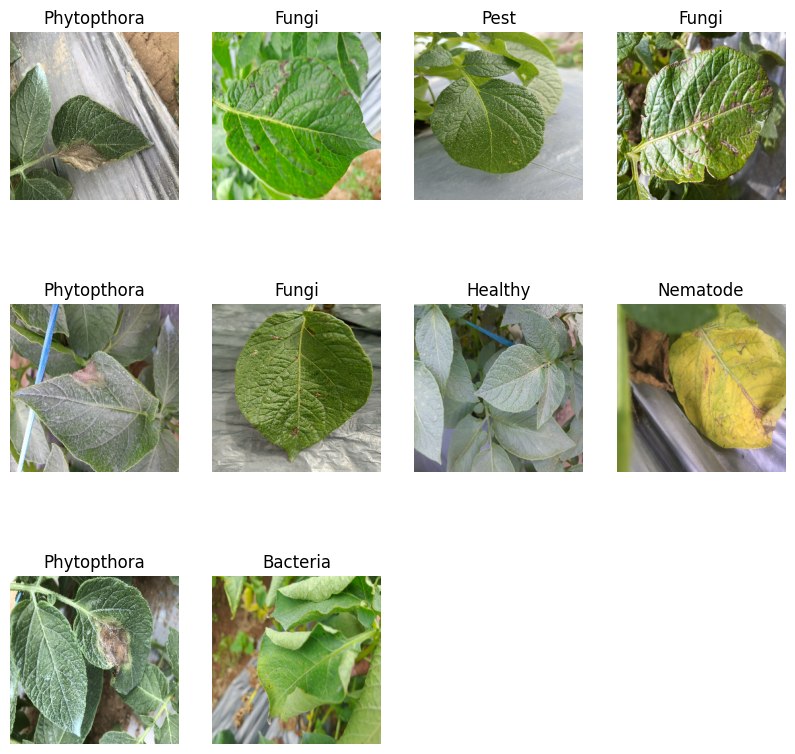

In [6]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in df.take(1):
  for i in range(10):
    ax=plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(classes[label_batch[i]])
    plt.axis("off")



In [7]:
def get_all_labels(ds):
    labels = []
    for image_batch, labels_batch in ds:
        labels.extend(labels_batch.numpy())
    return labels

In [8]:
labels = get_all_labels(df)
class_counts = {class_name: 0 for class_name in classes}
for label in labels:
    class_counts[classes[label]] += 1

In [9]:
import plotly.express as px
import pandas as pd
ds = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
fig = px.pie(ds, values='Count', names='Class', title='Proportion of Each Observed Category', hole=0.3,width=500, height=500)
fig.show()

In [10]:
train_df=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/potato-leaf-disease-dataset/Potato Leaf Disease Dataset in Uncontrolled Environment",
    seed=42,
    validation_split=0.3,
    subset="training",
    image_size=(256, 256),
    batch_size=32
)

temp_df=tf.keras.utils.image_dataset_from_directory(
        "/kaggle/input/potato-leaf-disease-dataset/Potato Leaf Disease Dataset in Uncontrolled Environment",
        seed=42,
        validation_split=0.3,
        subset="validation",
        image_size=(256, 256),
        batch_size=32
        

)

Found 3076 files belonging to 7 classes.
Using 2154 files for training.
Found 3076 files belonging to 7 classes.
Using 922 files for validation.


In [11]:
temp_df= temp_df.shuffle(
    buffer_size=1000,
    seed=42,
    reshuffle_each_iteration=False
)

temp_len = len(temp_df)
val_len = temp_len // 2

val_df= temp_df.take(val_len)
test_df= temp_df.skip(val_len)


In [12]:
def process(image,label):
  image=tf.cast(image,tf.float32)/255.0
  return image,label


In [13]:
train_df=train_df.map(process)
test_df=test_df.map(process)
val_df=val_df.map(process)

Okay so far we have done all the preprocessing , but if we look at the data it's pretty so we will apply data augmenation to create more  data

In [14]:
train_df = train_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_df = val_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_df = test_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
input_shape = (256,256,3)
num_classes = 7
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
], name="augmentation")


# Function to create DenseNet121 model
def create_densenet_model(input_shape):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True
    for layers in base_model.layers[:-50]:
        layers.trainable=False

    model = Sequential([
        tf.keras.Input(shape=input_shape),
        data_augmentation,     
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        Dense(264, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.5),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])

    return model

# Create the model
model = create_densenet_model(input_shape)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 264)            │       270,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 264)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 264)            │         1,056 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,326,575 (27.95 MB)

 Trainable params: 1,364,191 (5.20 MB)

 Non-trainable params: 5,962,384 (22.74 MB)

In [17]:
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


In [18]:
early_stop=EarlyStopping(patience=10,monitor='val_loss',start_from_epoch=10,restore_best_weights=True)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(
    'best_potato_densenet.keras',  # Saves to the current working directory
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [21]:
history=model.fit(train_df,epochs=100,validation_data=val_df,verbose=1,validation_steps=len(val_df),callbacks=[reduce_lr,early_stop,checkpoint])

Epoch 1/100


I0000 00:00:1769789323.266445      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2647 - loss: 2.1890
Epoch 1: val_accuracy improved from -inf to 0.46875, saving model to best_potato_densenet.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 56s 365ms/step - accuracy: 0.2656 - loss: 2.1854 - val_accuracy: 0.4688 - val_loss: 1.4646 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4596 - loss: 1.4987
Epoch 2: val_accuracy improved from 0.46875 to 0.64732, saving model to best_potato_densenet.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.4600 - loss: 1.4975 - val_accuracy: 0.6473 - val_loss: 0.9925 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5514 - loss: 1.2615
Epoch 3: val_accuracy improved from 0.64732 to 0.69420, saving model to best_potato_densenet.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 230ms/step - accuracy: 0.5518 - loss: 1.2604 - val_accuracy: 0.6942 - val_loss: 0.8831 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━

In [22]:
test_loss, test_accuracy = model.evaluate(test_df)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.8146 - loss: 0.5736
Test accuracy: 0.799578070640564
Test loss: 0.6007885932922363


In [23]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_df:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


Text(0.5, 1.0, 'confusionmatrix')

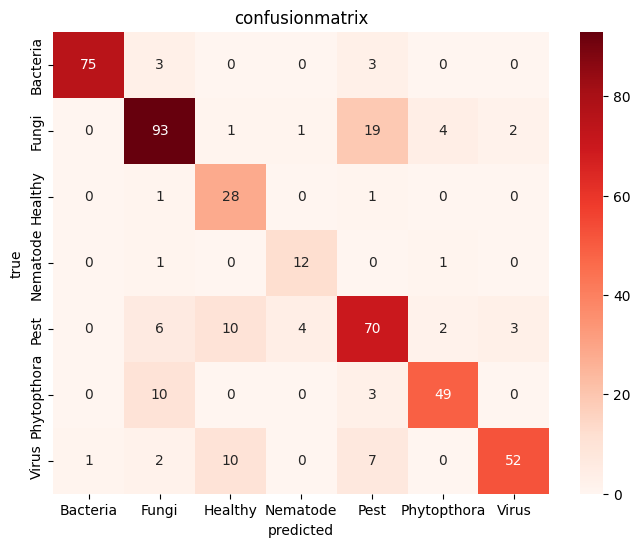

In [24]:
import seaborn as sns
from sklearn.metrics import  confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("predicted")
plt.ylabel("true")
plt.title("confusionmatrix")

In [25]:
print(classification_report(y_true, y_pred, target_names=classes))


              precision    recall  f1-score   support

    Bacteria       0.99      0.93      0.96        81
       Fungi       0.80      0.78      0.79       120
     Healthy       0.57      0.93      0.71        30
    Nematode       0.71      0.86      0.77        14
        Pest       0.68      0.74      0.71        95
 Phytopthora       0.88      0.79      0.83        62
       Virus       0.91      0.72      0.81        72

    accuracy                           0.80       474
   macro avg       0.79      0.82      0.80       474
weighted avg       0.82      0.80      0.80       474



In [26]:
import random
test_images=[]
test_labels=[]

for image,label in test_df:
    for i in range(len(images)):
        test_images.append(images[i])
        test_labels.append(labels[i])

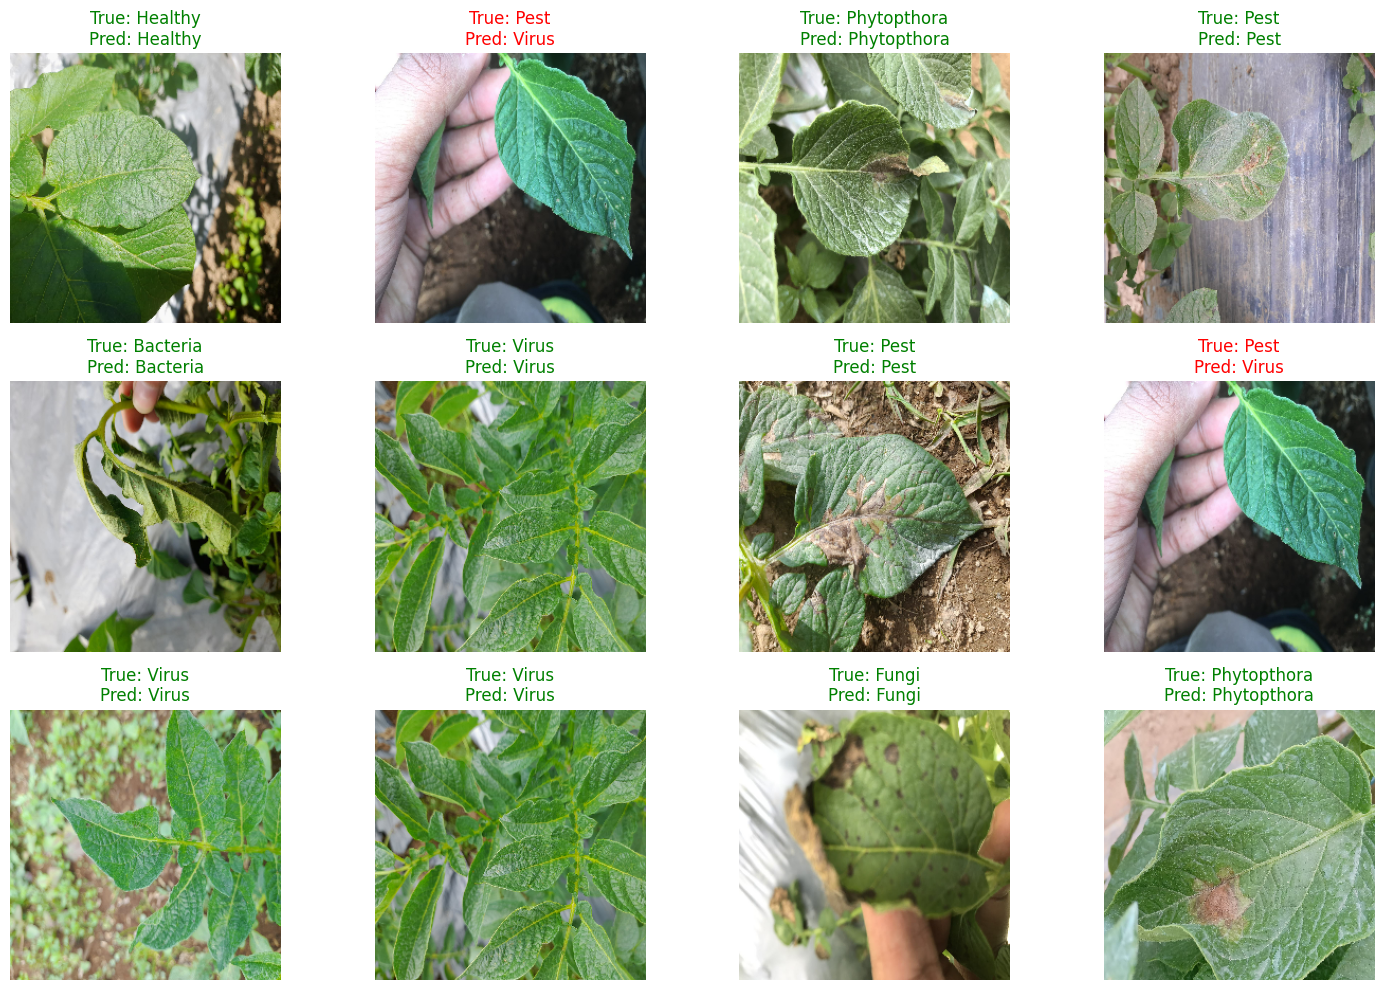

In [27]:
num_samples = 12  # you can change to 10–15
indices = random.sample(range(len(test_images)), num_samples)
plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    img = test_images[idx]
    true_label = classes[test_labels[idx]]

    pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)
    pred_label = classes[np.argmax(pred)]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()


In [28]:
best_model = tf.keras.models.load_model("/kaggle/working/best_potato_densenet.keras")
